In [31]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from collections import defaultdict

sys.path.append(str(Path().resolve().parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
from hyperparameters.hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [32]:
DATA_DIR = Path("../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [ ]:
def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_resnet_model_pretrained():
    model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    model.fc = nn.Linear(model.fc.in_features, 10)

    model = model.to(device)
    return model

def get_few_shot_indices(dataset, k_shots, seed):
    set_seed(seed)

    class_to_indices = defaultdict(list)
    
    for idx, (_, label) in enumerate(dataset):
        class_to_indices[label].append(idx)
    
    selected_indices = []
    
    for label, indices in class_to_indices.items():
        if len(indices) < k_shots:
            raise ValueError(f"Class {label} has less than {k_shots} samples!")
        
        chosen = np.random.choice(indices, k_shots, replace=False)
        selected_indices.extend(chosen)
    
    return selected_indices

def test_few_shot_learning(model, train_loader, valid_loader, test_loader, k_shots,
                         seeds, scheduler=None, device=None, num_epochs=20):
    

    results = {}
    full_train_ds = train_loader.dataset
    batch_size = train_loader.batch_size

    for k in k_shots:
        results[k] = {}
        for seed in seeds:
            print(f"\nK-SHOTS={k} | SEED={seed}")
            set_seed(seed)

            indices = get_few_shot_indices(full_train_ds, k, seed)
            train_subset = Subset(full_train_ds, indices)

            subset_loader = DataLoader(train_subset, batch_size=len(train_subset), shuffle=True)
        
            model_instance = model()
            model_instance = model_instance.to(device)
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)
            
            print("------------------------------------------------------")
            history = train(model_instance, subset_loader, valid_loader, criterion, optimizer,
                scheduler=scheduler, device=device, num_epochs=num_epochs, verbose=True, verbose_interval=max(1, int(num_epochs / 10)))
            
            validation_accuracy = history['valid_acc'][-1]
            validation_loss     = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(model_instance, test_loader, criterion, device)
            
            results[k][seed] = {
                "history":    history,
                "valid_acc":  validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc":   test_accuracy,
                "test_loss":  test_loss
            }
            
            print("------------------------------------------------------")
            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")
            print("------------------------------------------------------")
    
    return results

In [34]:
K_SHOTS = [1, 5, 10, 20, 25]
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [35]:
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=32, batch_size=BATCH_SIZE)

#### Resnet

In [23]:
resnet_results = test_few_shot_learning(model=create_resnet_model, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, k_shots=K_SHOTS, seeds=SEEDS, num_epochs=20, device=device)


K-SHOTS=1 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 0.4360 | Valid Loss: 2.2909 | Valid Acc: 0.1083
Epoch 4/20 | Train Loss: 0.0069 | Valid Loss: 2.2799 | Valid Acc: 0.1423
Epoch 6/20 | Train Loss: 0.0028 | Valid Loss: 2.2901 | Valid Acc: 0.1316
Epoch 8/20 | Train Loss: 0.0014 | Valid Loss: 2.3239 | Valid Acc: 0.1227
Epoch 10/20 | Train Loss: 0.0009 | Valid Loss: 2.3891 | Valid Acc: 0.1183
Epoch 12/20 | Train Loss: 0.0006 | Valid Loss: 2.4918 | Valid Acc: 0.1158
Epoch 14/20 | Train Loss: 0.0004 | Valid Loss: 2.6305 | Valid Acc: 0.1151
Epoch 16/20 | Train Loss: 0.0004 | Valid Loss: 2.7960 | Valid Acc: 0.1154
Epoch 18/20 | Train Loss: 0.0003 | Valid Loss: 2.9744 | Valid Acc: 0.1160
Epoch 20/20 | Train Loss: 0.0003 | Valid Loss: 3.1514 | Valid Acc: 0.1165
Best validation accuracy: 0.1423
------------------------------------------------------
VALIDATION ACCURACY: 0.1165 | TEST ACCURACY: 0.1163
-------------------------------------------------

In [24]:
save_results(resnet_results, 'results_resnet.json')

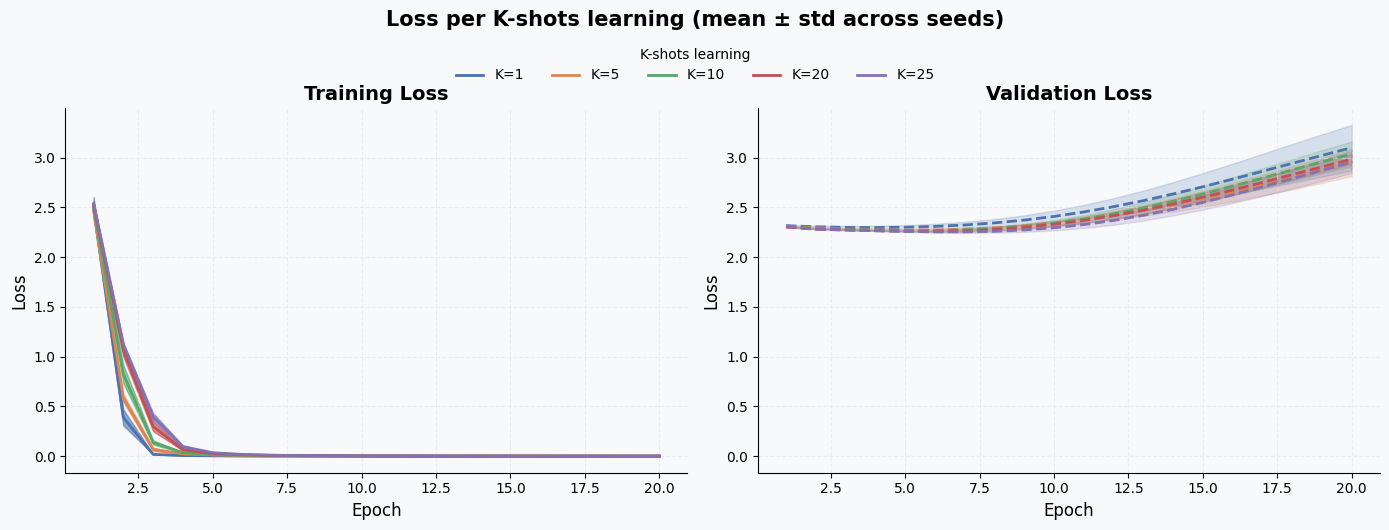

In [25]:
plot_loss_comparison(resnet_results, param_name="K-shots learning", param_name_short = 'K')

In [26]:
for param, seed_dict in resnet_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"lr={param} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

lr=1 | seeds=3 | max std=0.097134
lr=5 | seeds=3 | max std=0.051933
lr=10 | seeds=3 | max std=0.091792
lr=20 | seeds=3 | max std=0.065778
lr=25 | seeds=3 | max std=0.037151


In [27]:
df = summarize_results(resnet_results)
df

,Model,lr,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,1,0.117996,0.005293,3.099217,0.228700,0.118133,0.003702,3.096277,0.219337
1,Model,5,0.155226,0.001884,2.949716,0.136210,0.155174,0.001376,2.950687,0.134946
2,Model,10,0.153330,0.016513,3.037260,0.123292,0.153578,0.018467,3.035773,0.124177
3,Model,20,0.170452,0.018800,2.983239,0.049222,0.169467,0.016255,2.984893,0.044740
4,Model,25,0.177837,0.010358,2.955215,0.111800,0.177811,0.010195,2.957702,0.108900


In [28]:
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,1,0.1180 ± 0.0053,3.0992 ± 0.2287,0.1181 ± 0.0037,3.0963 ± 0.2193
1,Model,5,0.1552 ± 0.0019,2.9497 ± 0.1362,0.1552 ± 0.0014,2.9507 ± 0.1349
2,Model,10,0.1533 ± 0.0165,3.0373 ± 0.1233,0.1536 ± 0.0185,3.0358 ± 0.1242
3,Model,20,0.1705 ± 0.0188,2.9832 ± 0.0492,0.1695 ± 0.0163,2.9849 ± 0.0447
4,Model,25,0.1778 ± 0.0104,2.9552 ± 0.1118,0.1778 ± 0.0102,2.9577 ± 0.1089


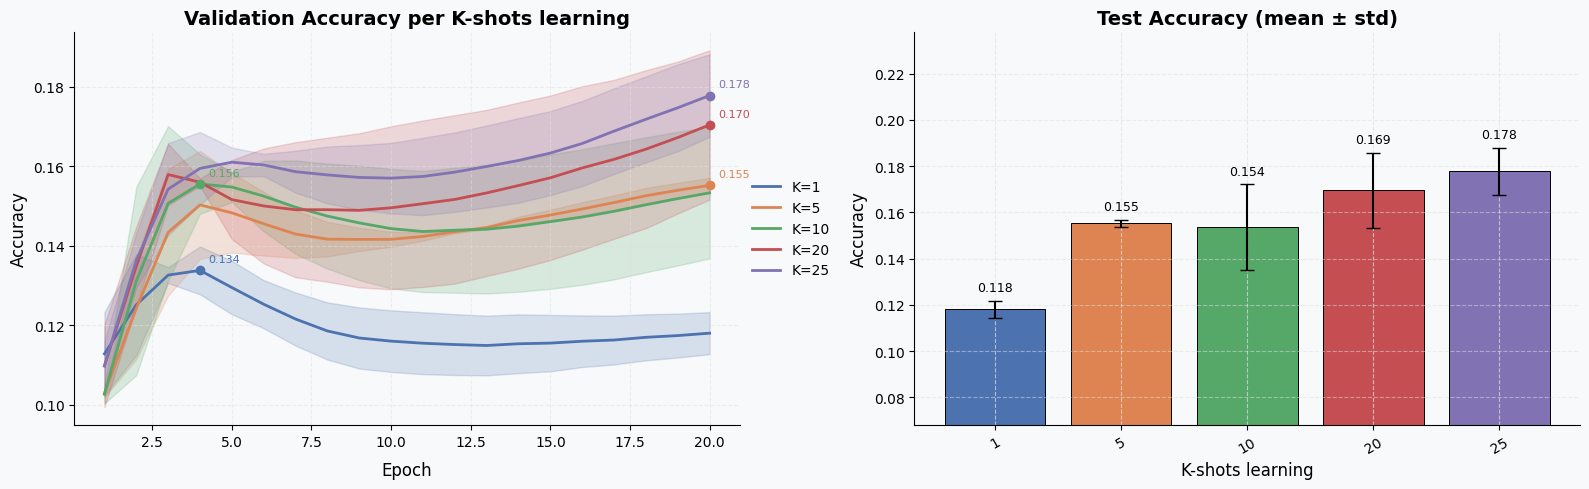

In [29]:
plot_accuracy_comparison(resnet_results, param_name="K-shots learning", param_name_short = 'K')

#### Resnet pretrained

In [36]:
resnet_pretrained_results = test_few_shot_learning(model=create_resnet_model_pretrained, train_loader=train_loader, valid_loader=valid_loader,
    test_loader=test_loader, k_shots=K_SHOTS, seeds=SEEDS, num_epochs=20, device=device)


K-SHOTS=1 | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 0.2825 | Valid Loss: 2.7738 | Valid Acc: 0.1345
Epoch 4/20 | Train Loss: 0.0030 | Valid Loss: 2.9745 | Valid Acc: 0.1315
Epoch 6/20 | Train Loss: 0.0011 | Valid Loss: 3.0106 | Valid Acc: 0.1313
Epoch 8/20 | Train Loss: 0.0006 | Valid Loss: 2.9601 | Valid Acc: 0.1296
Epoch 10/20 | Train Loss: 0.0004 | Valid Loss: 2.8788 | Valid Acc: 0.1276
Epoch 12/20 | Train Loss: 0.0003 | Valid Loss: 2.8141 | Valid Acc: 0.1263
Epoch 14/20 | Train Loss: 0.0002 | Valid Loss: 2.8078 | Valid Acc: 0.1255
Epoch 16/20 | Train Loss: 0.0002 | Valid Loss: 2.8820 | Valid Acc: 0.1229
Epoch 18/20 | Train Loss: 0.0002 | Valid Loss: 3.0223 | Valid Acc: 0.1229
Epoch 20/20 | Train Loss: 0.0001 | Valid Loss: 3.1947 | Valid Acc: 0.1229
Best validation accuracy: 0.1354
------------------------------------------------------
VALIDATION ACCURACY: 0.1229 | TEST ACCURACY: 0.1248
-------------------------------------------------

In [37]:
save_results(resnet_pretrained_results, 'results_pretrained_resnet.json')

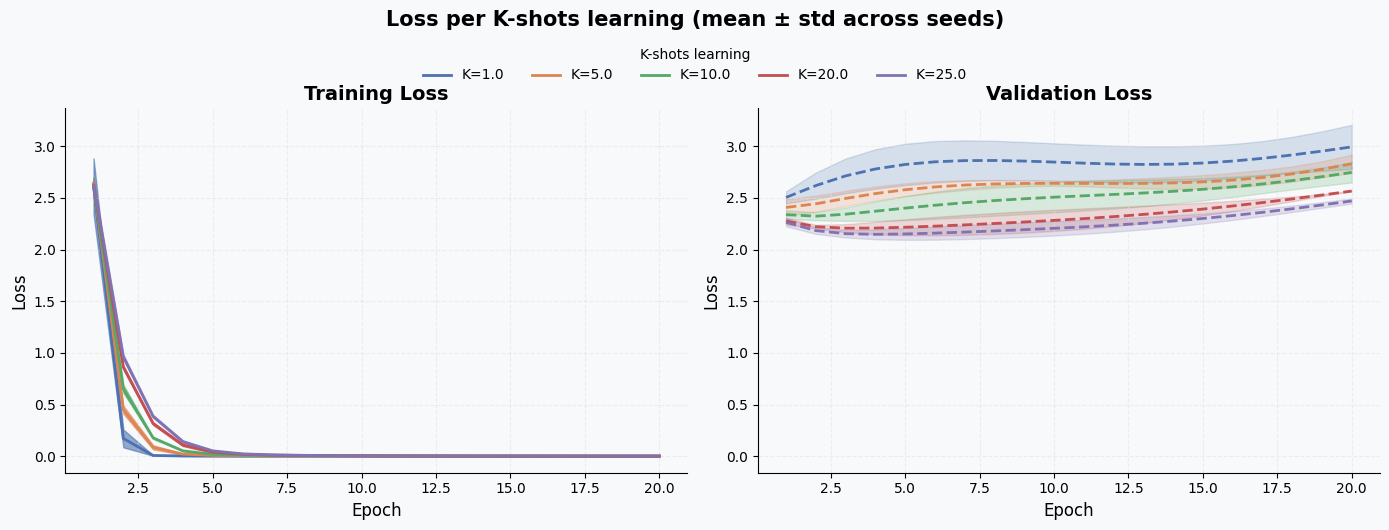

In [39]:
plot_loss_comparison(resnet_pretrained_results, param_name="K-shots learning", param_name_short = 'K')

In [42]:
df = summarize_results(resnet_pretrained_results)
print_summary_table(df, hyperparameter='lr')

,Model,lr,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,1.0,0.1406 ± 0.0200,2.9949 ± 0.2130,0.1402 ± 0.0189,2.9978 ± 0.2125
1,Model,5.0,0.1937 ± 0.0063,2.8313 ± 0.0881,0.1935 ± 0.0059,2.8329 ± 0.0828
2,Model,10.0,0.2303 ± 0.0077,2.7477 ± 0.0981,0.2296 ± 0.0084,2.7447 ± 0.0959
3,Model,20.0,0.2751 ± 0.0015,2.5675 ± 0.0036,0.2759 ± 0.0012,2.5701 ± 0.0113
4,Model,25.0,0.2942 ± 0.0056,2.4711 ± 0.0251,0.2935 ± 0.0038,2.4725 ± 0.0220


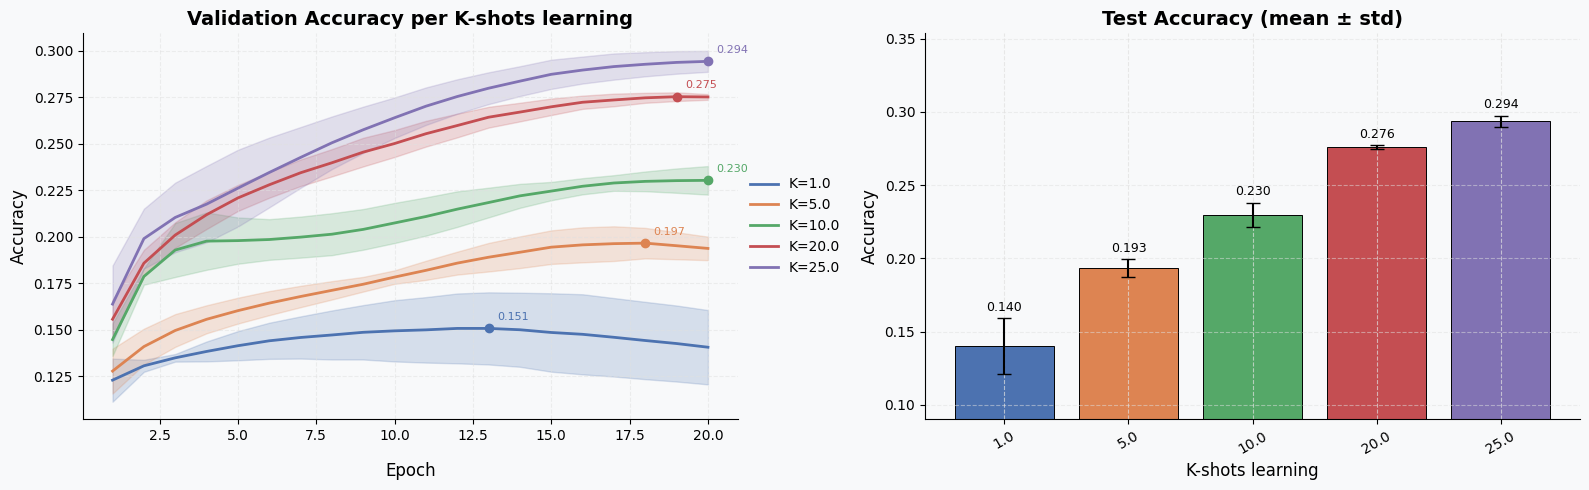

In [43]:
plot_accuracy_comparison(resnet_pretrained_results, param_name="K-shots learning", param_name_short = 'K')